In [4]:
# Core libraries
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# YOLO
from ultralytics import YOLO

# Clustering
from sklearn.cluster import KMeans

import torch
from ultralytics.nn.tasks import DetectionModel

torch.load = lambda *args, **kwargs: __import__("torch").serialization.load(*args, weights_only=False, **kwargs)

model = YOLO("/home/gholfes/project/runs/detect/train4/weights/best.pt")

# Make the path start at the "tracknet" folder 
base_path = "/home/gholfes/project/tracknet/Dataset"

# Lists every item in "tracknet" and stores it in games
games = os.listdir(base_path)

all_data = {}


In [5]:


# Loop through each individual game 
for game in games:
    # Make the folder path to avoid string errors
    
    game_path = os.path.join(base_path, game)
    
    # Get all clips in each game 
    clips = os.listdir(game_path) 
    
    all_data[game] = {}
    
    # Go through each clip (rallies/sequences)
    for clip in clips[:5]:
        trajectory = []
        frame_id = 0   # reset per clip
        
        # Build path to clip to avoid errors 
        clip_path = os.path.join(game_path, clip)
        
        # Sorts the frames so each clip isn't chopped up
        frames = sorted(glob.glob(os.path.join(clip_path, "*.jpg")))
           
        # Go image by image and gather postions of balls 
        for f in frames:
            
            # Get boxes and confidence scores from a frame
            results = model(f)
            
            for r in results:
                boxes = r.boxes
                
                # Check if YOLO actually found something (players, tennis balls)
                if boxes is None or len(boxes) == 0:
                    continue
                
                # Takes care of YOLO accidently tracking multiple balls
                
                # Resets every frame so you only keep one detection
                best_box = None
                best_conf = 0
                
                # Loop through every detection (Players, Ball, Officals)
                for box in boxes:
                    cls_id = int(box.cls[0])
                    label = model.names[cls_id]
                    
                    # Ignore everything but tennis balls (Tennis ball label == 2)
                    if cls_id != 2:
                        continue
                    
                    # Get the confidence of how sure yolo is something is a tennis ball
                    conf = float(box.conf[0])
                    
                    # Get the best detected ball per frame (if theres two being detected)
                    if conf > best_conf:
                        best_conf = conf
                        best_box = box
                
                # Only run if a ball is found
                if best_box is not None:
                    
                    # Get top left and bottom right coordinates and find the middle
                    x1, y1, x2, y2 = best_box.xyxy[0].tolist()
                    
                    x = (x1 + x2) / 2
                    y = (y1 + y2) / 2
                    
                    # Add the middle and ID to trajectory
                    trajectory.append([frame_id, float(x), float(y)])
                                       
            # Increase frame ID
            frame_id += 1


    

        # Turn trajectory (X and Y values) into a excel style sheet 
        df = pd.DataFrame (trajectory, columns=["frame_id", "x", "y"])
        df = df.sort_values("frame_id").reset_index(drop=True)


        # Interpolate missing frames
        df = df.set_index("frame_id")
        df = df.reindex(range(df.index.min(), df.index.max()))

        df["x"] = df["x"].interpolate()
        df["y"] = df["y"].interpolate()

        df = df.reset_index()


        all_data[game][clip] = df


/home/gholfes/.local/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0



image 1/1 /home/gholfes/project/tracknet/Dataset/game1/Clip1/0000.jpg: 384x640 1 official, 2 playerss, 177.0ms
Speed: 8.4ms preprocess, 177.0ms inference, 18.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/gholfes/project/tracknet/Dataset/game1/Clip1/0001.jpg: 384x640 1 official, 2 playerss, 68.9ms
Speed: 1.7ms preprocess, 68.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/gholfes/project/tracknet/Dataset/game1/Clip1/0002.jpg: 384x640 1 official, 2 playerss, 60.5ms
Speed: 1.8ms preprocess, 60.5ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/gholfes/project/tracknet/Dataset/game1/Clip1/0003.jpg: 384x640 1 official, 2 playerss, 1 tennis_ball, 59.8ms
Speed: 2.7ms preprocess, 59.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/gholfes/project/tracknet/Dataset/game1/Clip1/0004.jpg: 384x640 1 official, 2 playerss, 1 tennis_ball, 60.2ms
Speed: 2.7ms preprocess,

===== .ipynb_checkpoints =====
===== game1 =====


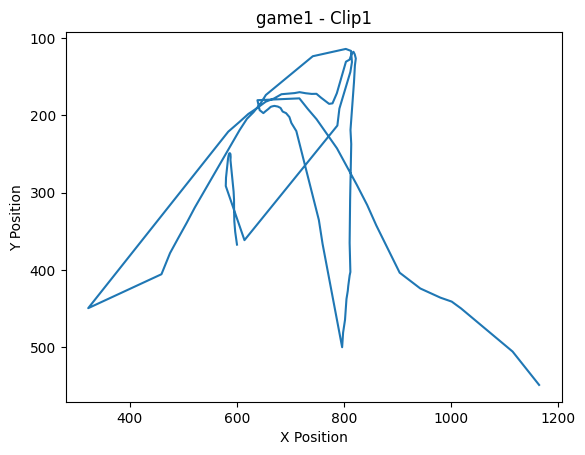

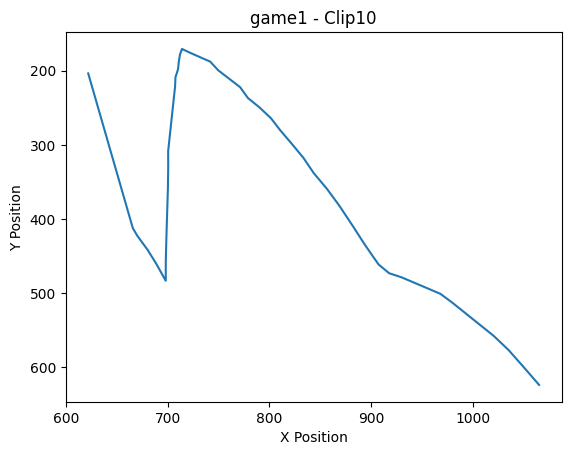

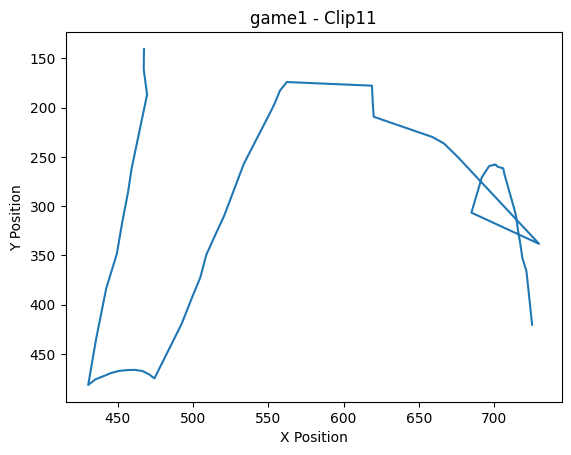

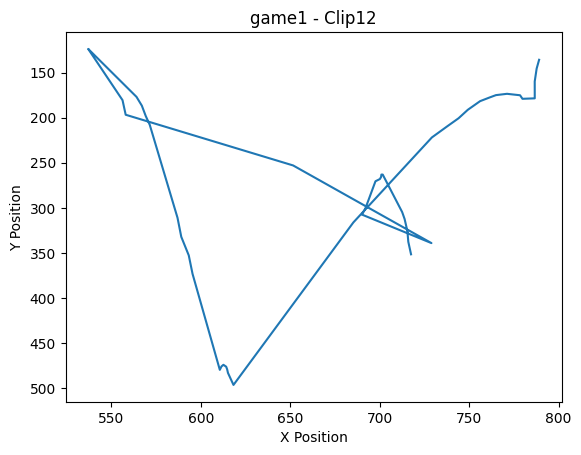

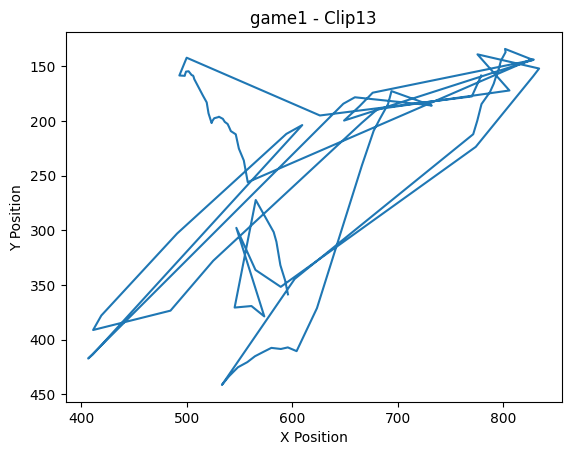

===== game10 =====


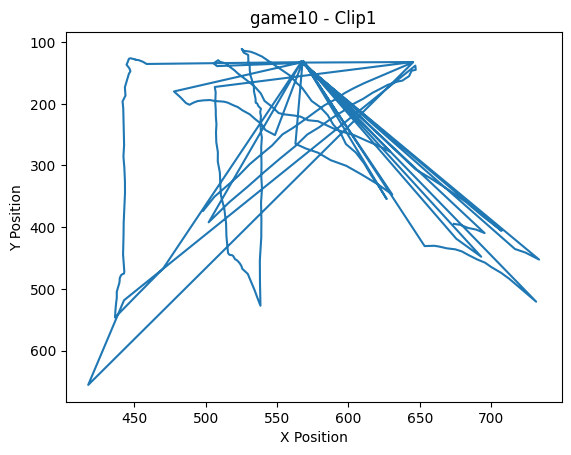

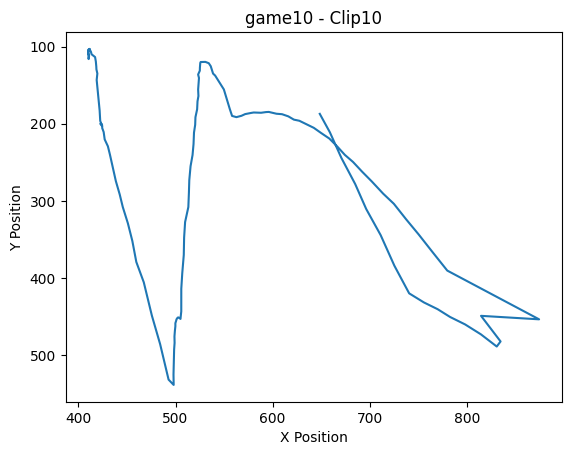

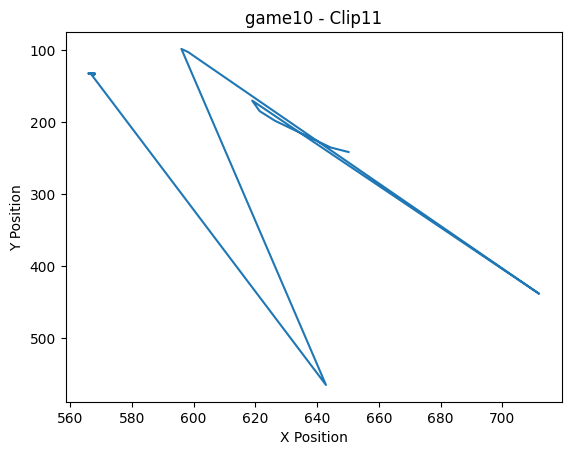

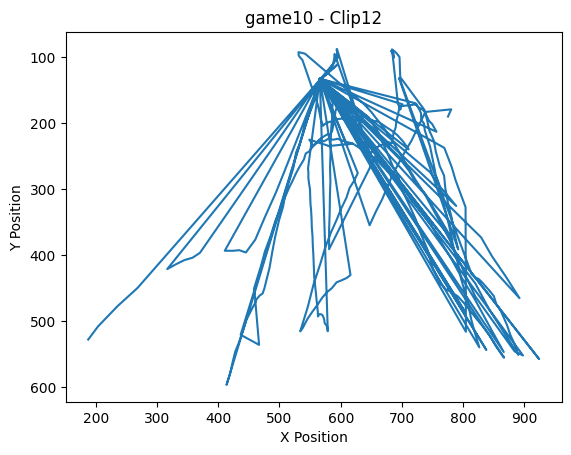

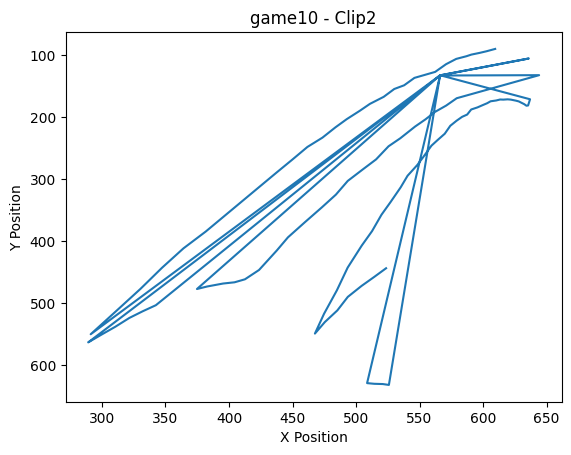

===== game2 =====


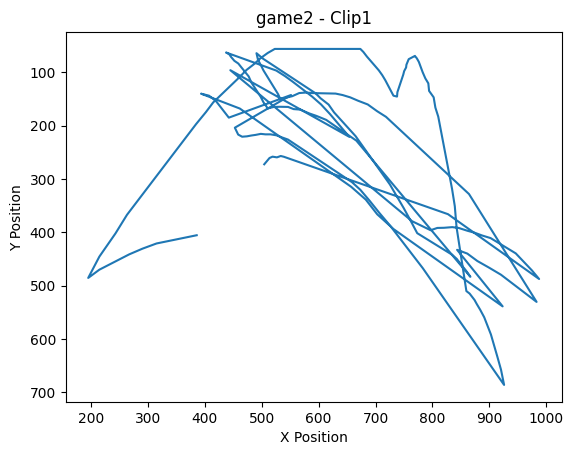

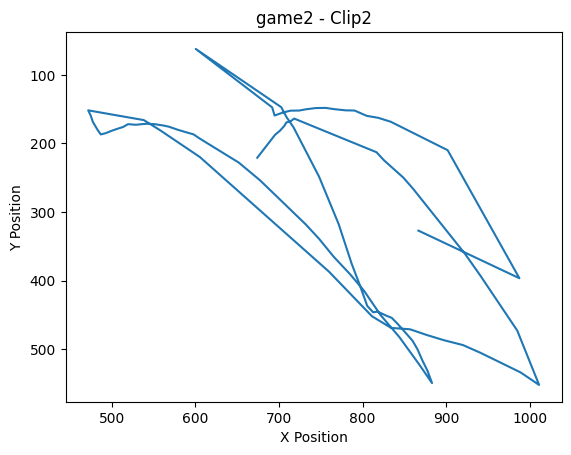

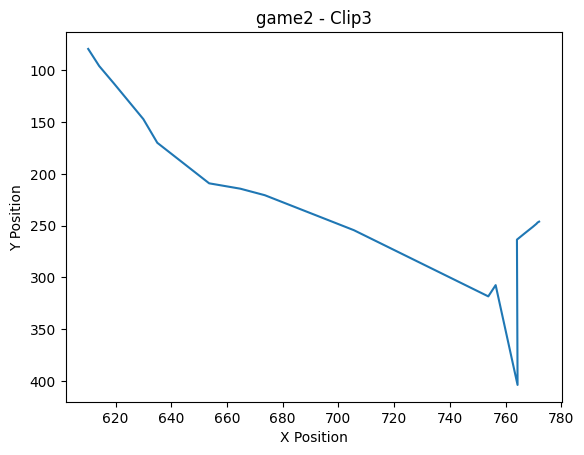

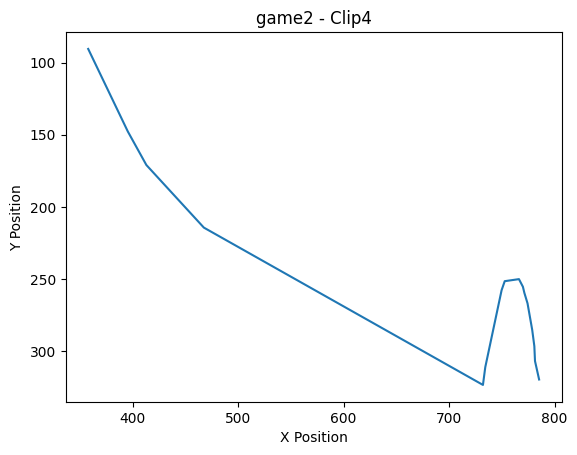

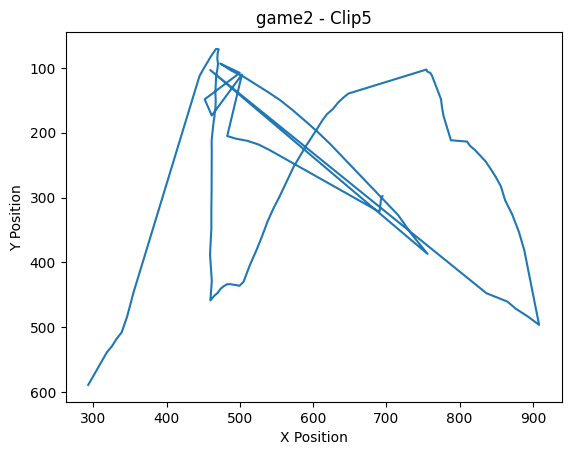

===== game3 =====


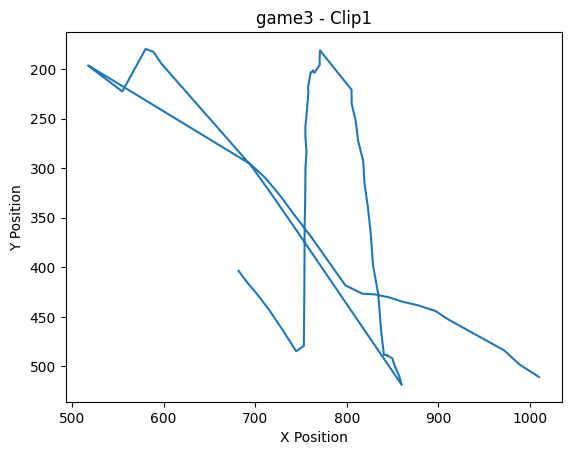

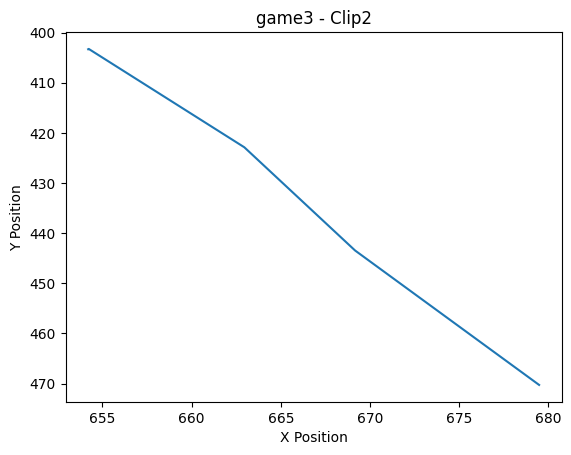

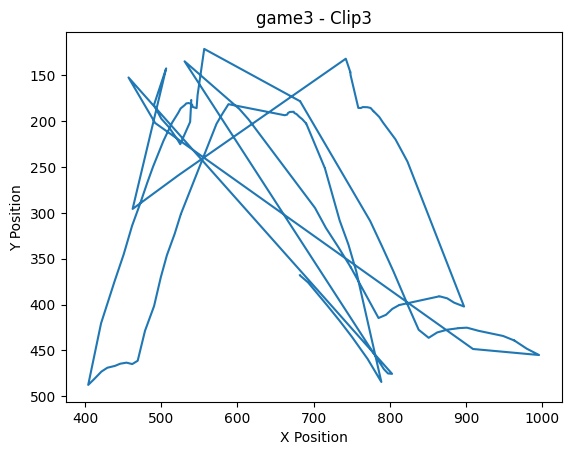

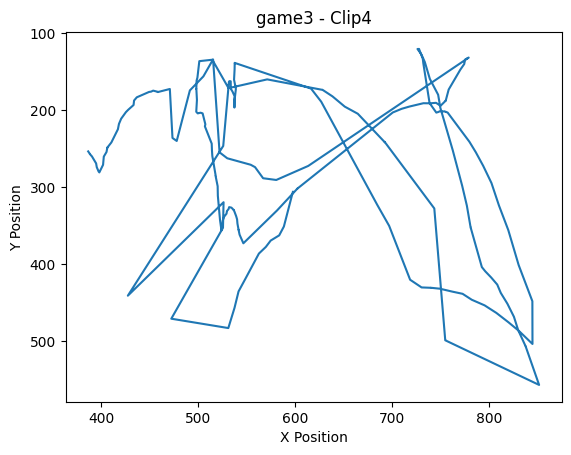

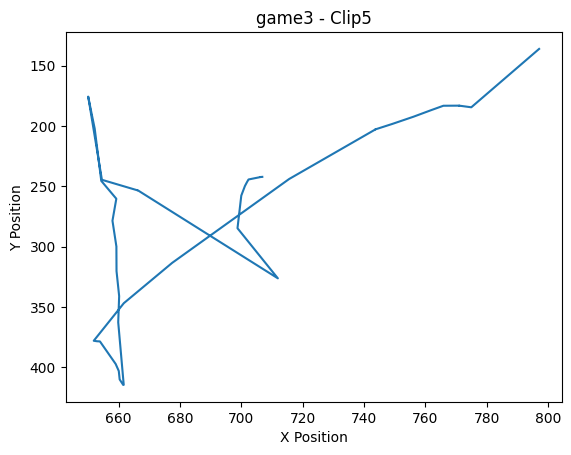

===== game4 =====


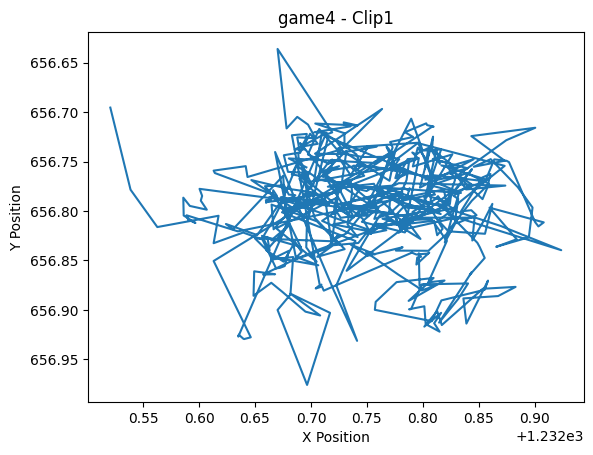

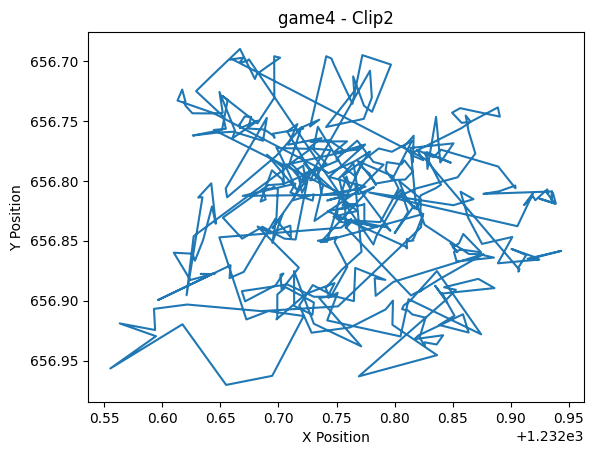

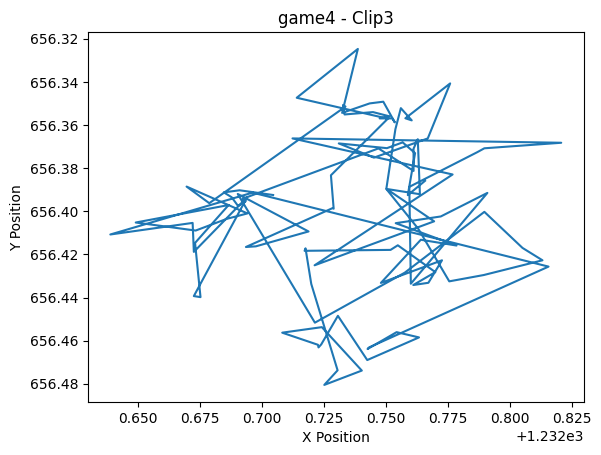

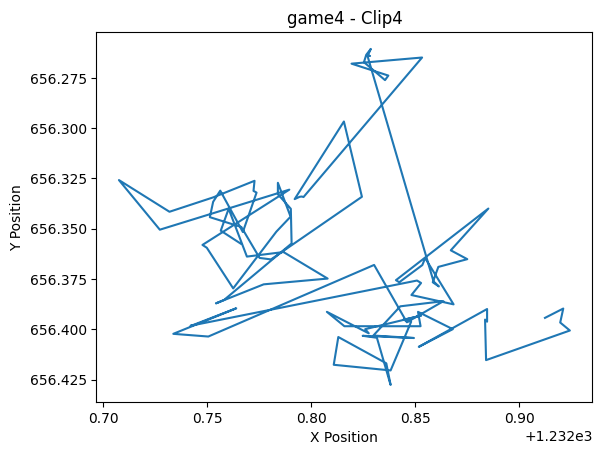

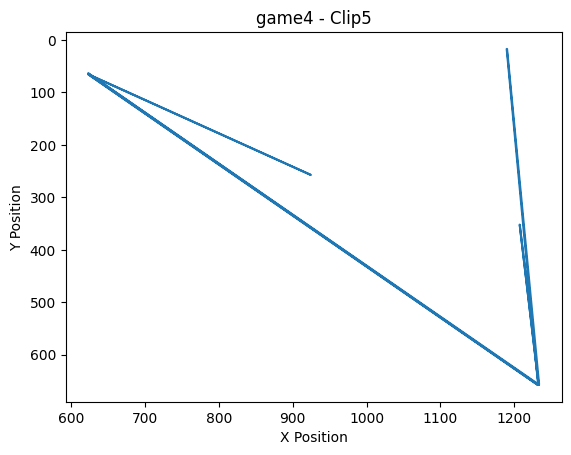

===== game5 =====


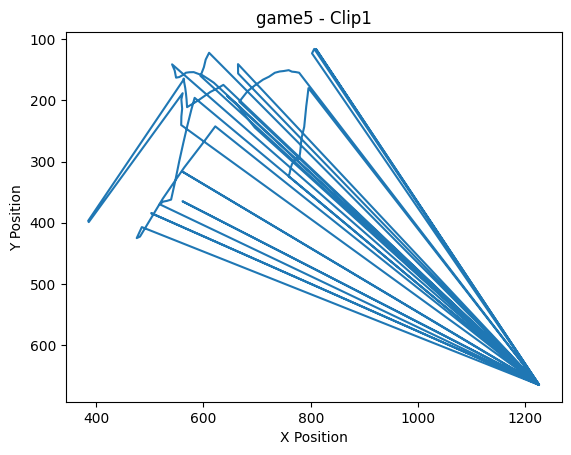

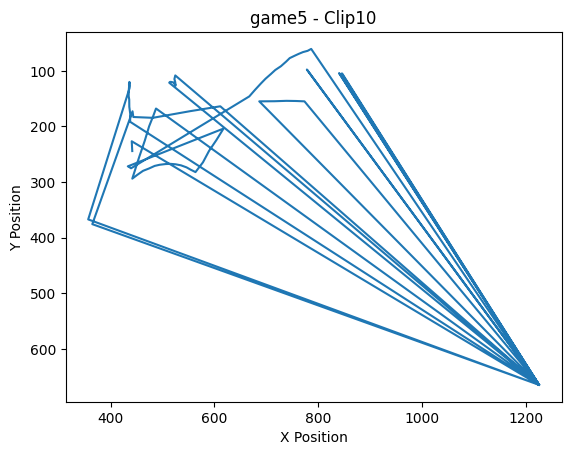

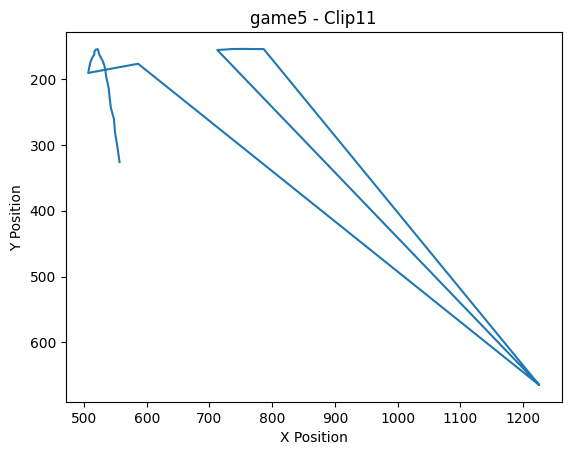

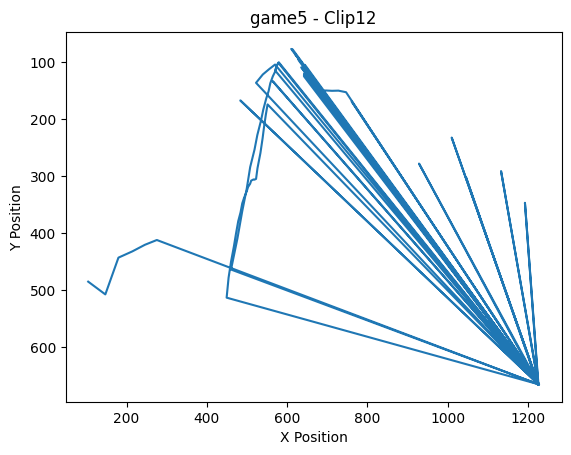

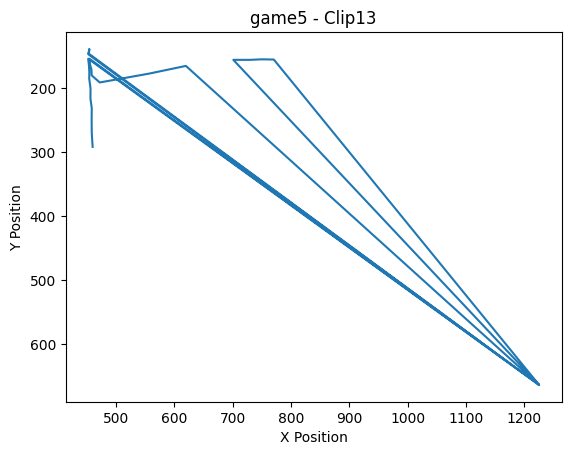

===== game6 =====


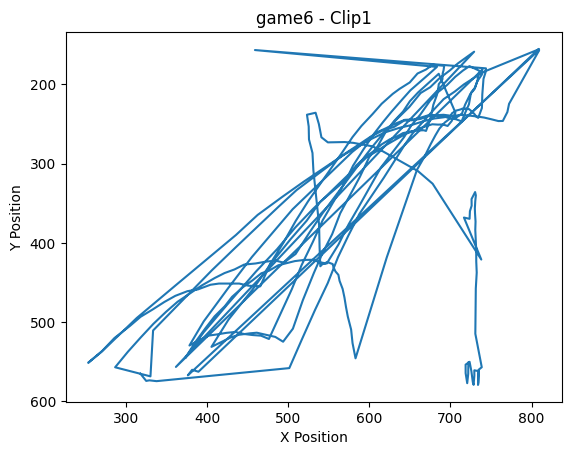

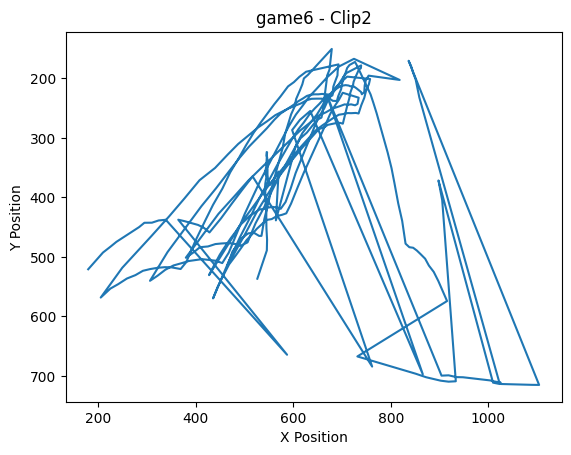

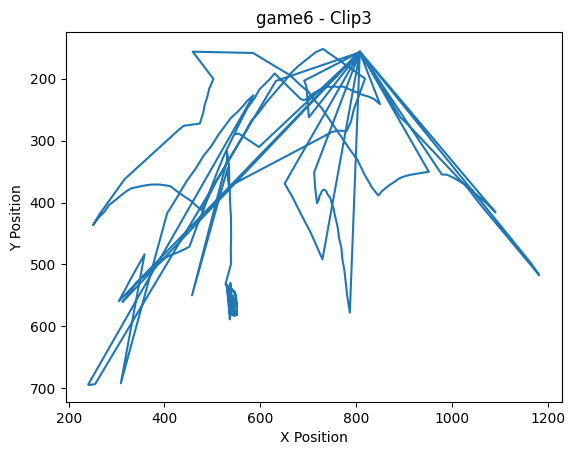

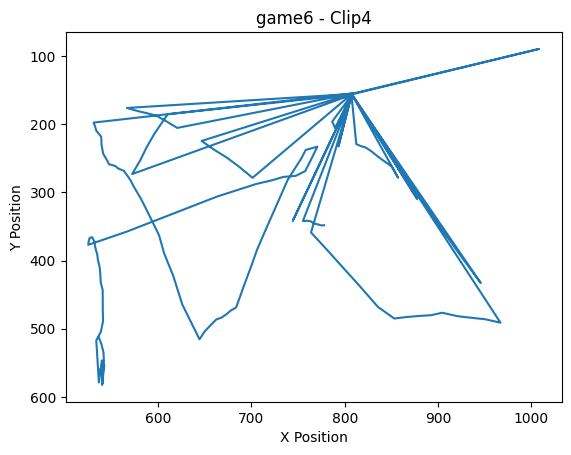

===== game7 =====


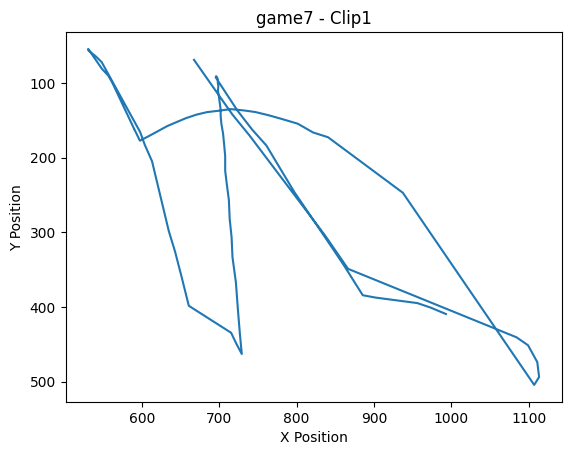

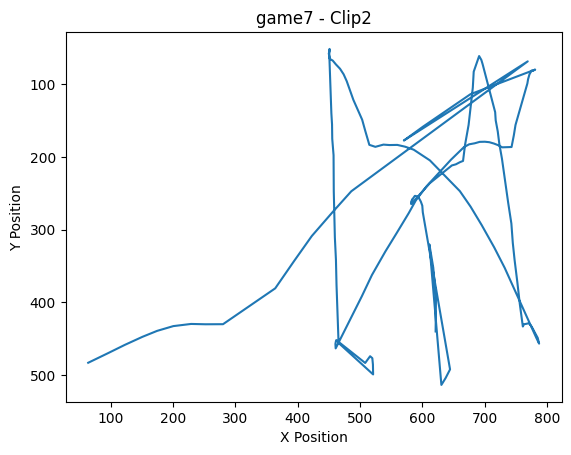

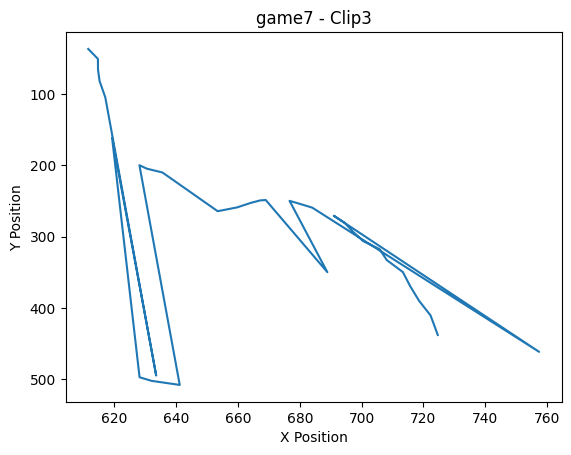

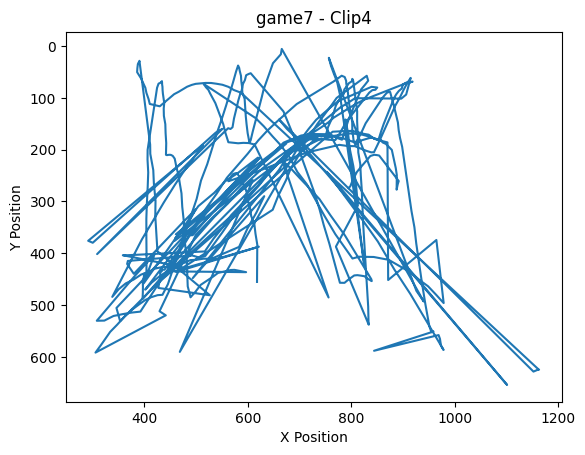

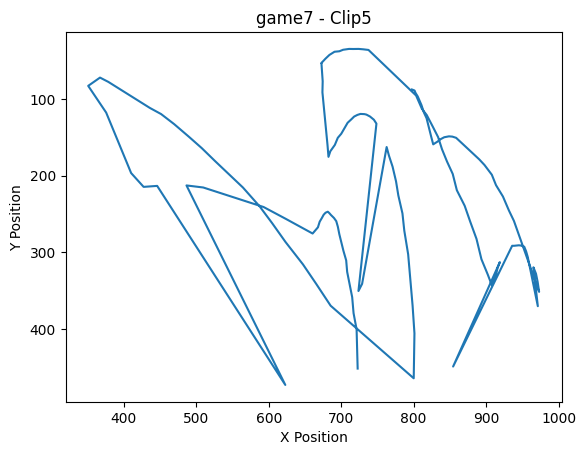

===== game8 =====


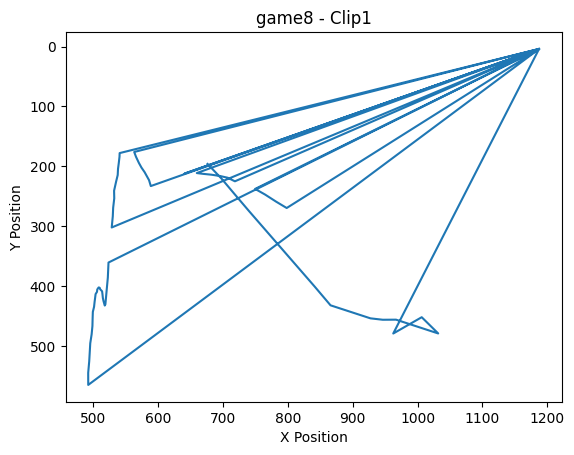

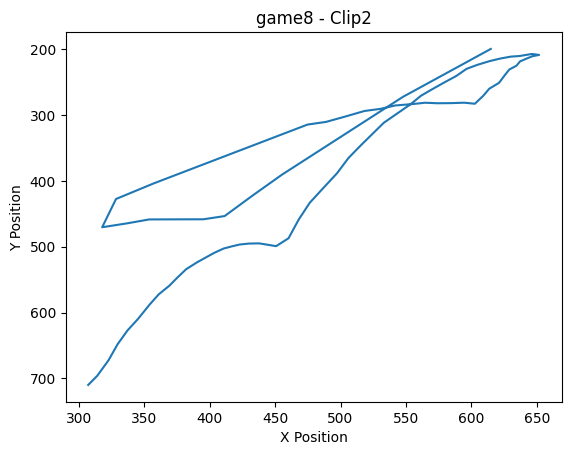

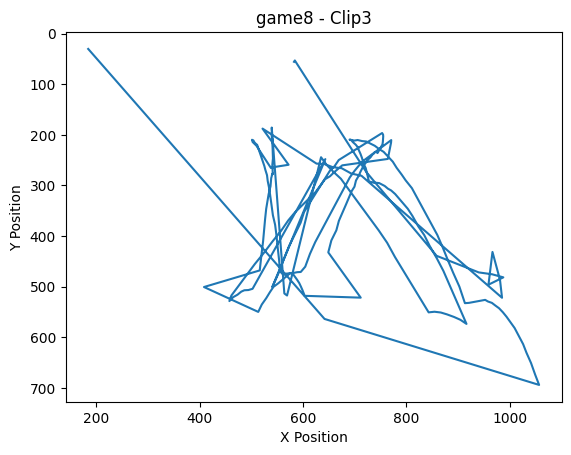

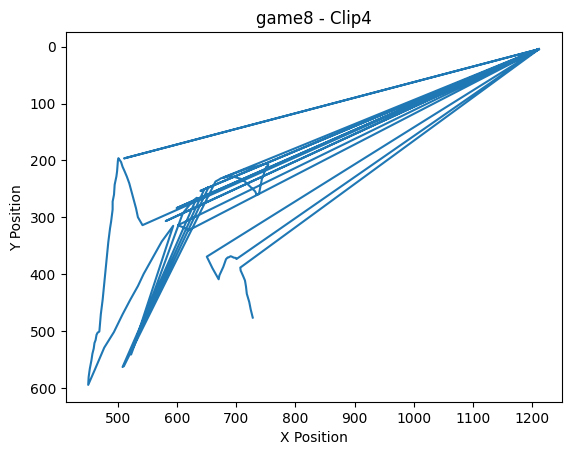

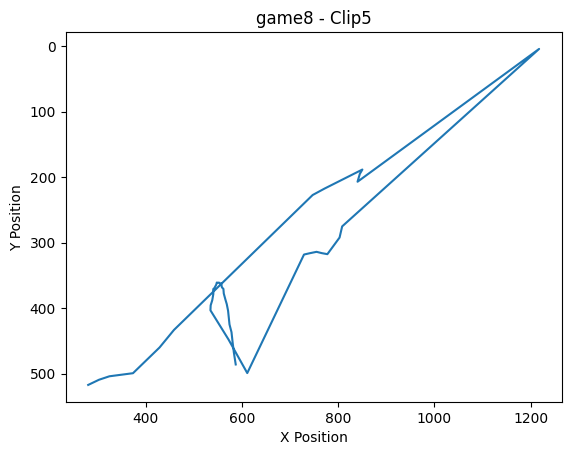

===== game9 =====


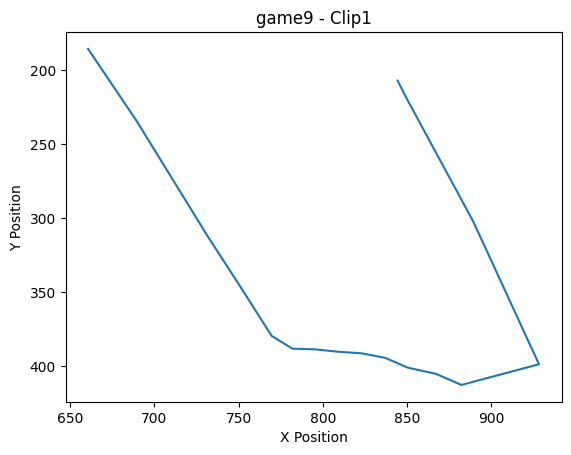

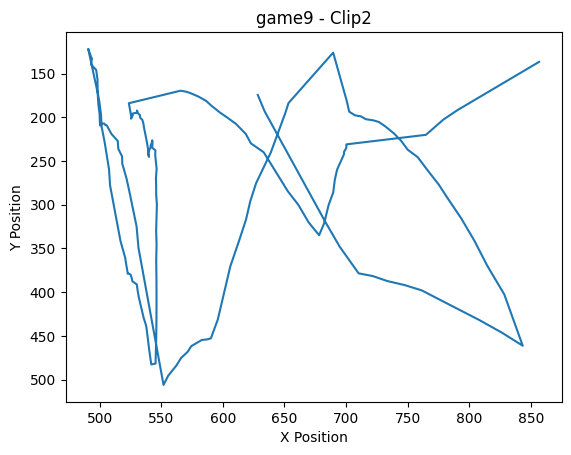

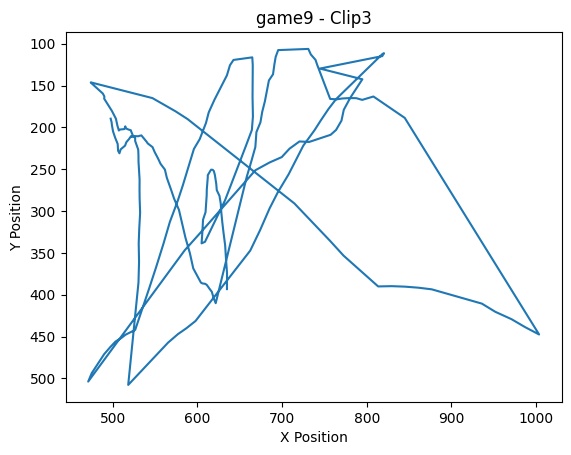

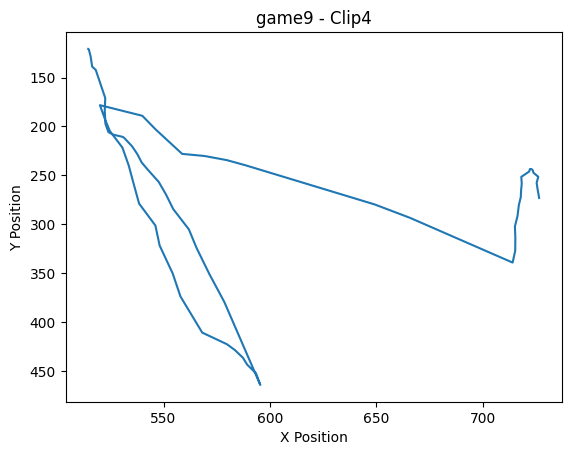

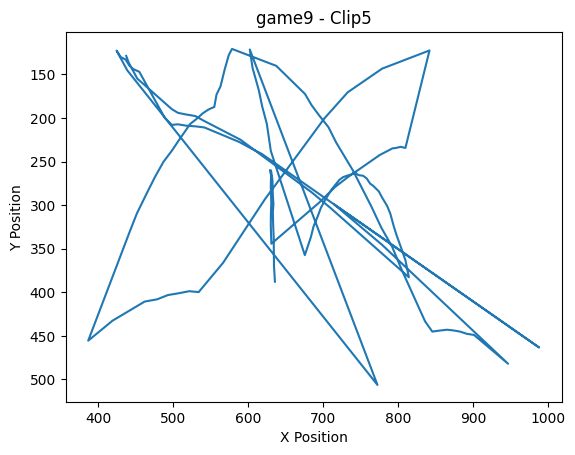

In [6]:
for game in all_data:
    print(f"===== {game} =====")
    
    for clip in all_data[game]:
        
        df = all_data[game][clip]
        
        plt.figure()
        
        plt.plot(df["x"], df["y"])
        plt.gca().invert_yaxis()
        
        plt.title(f"{game} - {clip}")
        plt.xlabel("X Position")
        plt.ylabel("Y Position")
        
        plt.show()

In [7]:
all_bounces = {}

# Make sure we only use real game folders (ignore .ipynb_checkpoints)
games = [g for g in all_data if not g.startswith(".")]

for game in games:
    clips_bounce_pos = []
    
    # Id for each clip
    clip_id = 0
    
    for clip in all_data[game]:
        
        # Get dataframe for this clip
        df = all_data[game][clip]
        
        # Skip bad clips with too little data
        if len(df) < 5:
            clip_id += 1
            continue
        
        # Location of where the serve bounce was detected
        serve_bounce_x = 0.0
        serve_bounce_y = 0.0
        
        # Store all possible bounce candidates
        bounce_candidates = []
        
        # For every frame in clip find ALL possible bounces
        for i in range(5, len(df) - 1):
            y_prev = df.iloc[i - 1]["y"]
            y_current = df.iloc[i]["y"]
            y_after = df.iloc[i+1]["y"]
            
            velocity_before = y_current - y_prev
            velocity_after = y_after - y_current
            
            # If the velocity changes trajectory (+ to -), this is a bounce candidate
            if velocity_before > 0 and velocity_after < 0:
                
                # Strength of bounce (bigger = more likely to be a real bounce)
                strength = abs(velocity_before) + abs(velocity_after)
                
                bounce_candidates.append([i, strength])
        
        # If any bounce candidates are found pick the strongest one
        if len(bounce_candidates) > 0:
            
            # Get the index of the strongest bounce
            best_bounce = max(bounce_candidates, key=lambda x: x[1])
            bounce_index = best_bounce[0]
            
            # Get x and y position of that bounce
            serve_bounce_x = df.iloc[bounce_index]["x"]
            serve_bounce_y = df.iloc[bounce_index]["y"]
            
            clips_bounce_pos.append([clip_id, serve_bounce_x, serve_bounce_y])
        
        # If no bounce was found skip instead of adding garbage data
        clip_id += 1
        
    serve_df = pd.DataFrame (clips_bounce_pos, columns=["clip_id", "serve_x", "serve_y"])
    serve_df = serve_df.sort_values("clip_id").reset_index(drop=True)
    
    # Store per game
    all_bounces[game] = serve_df
        
                
                
            
        

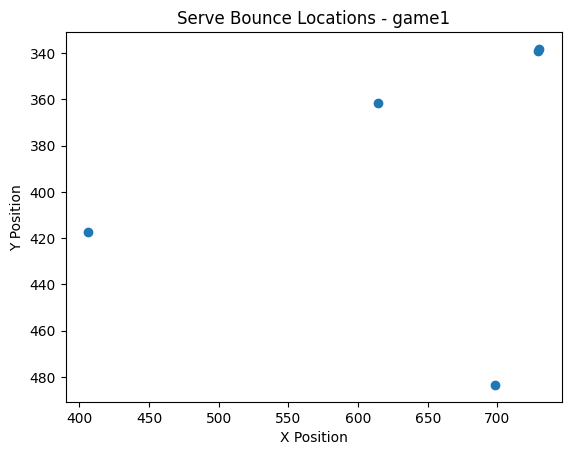

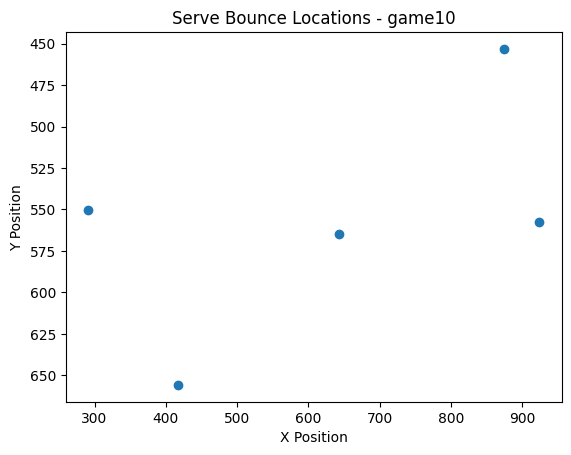

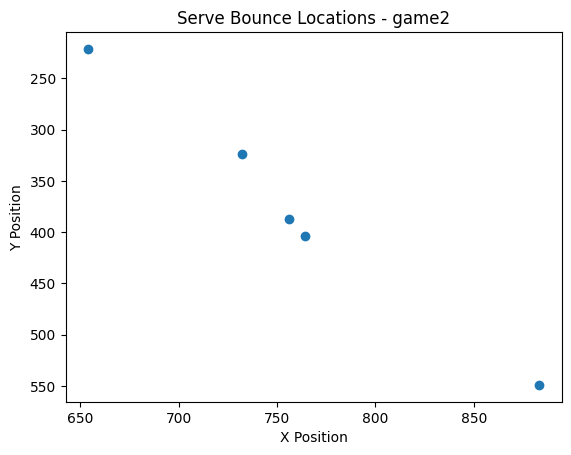

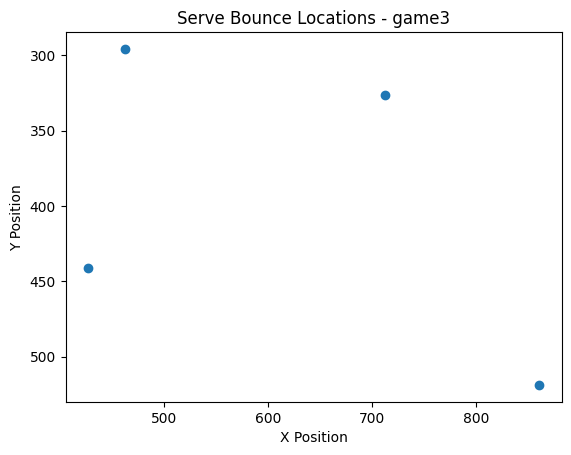

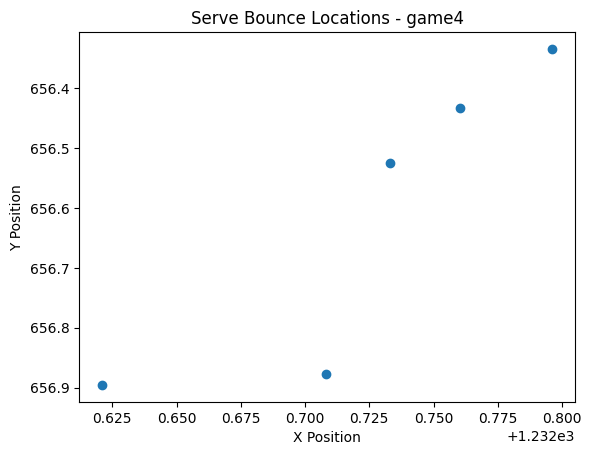

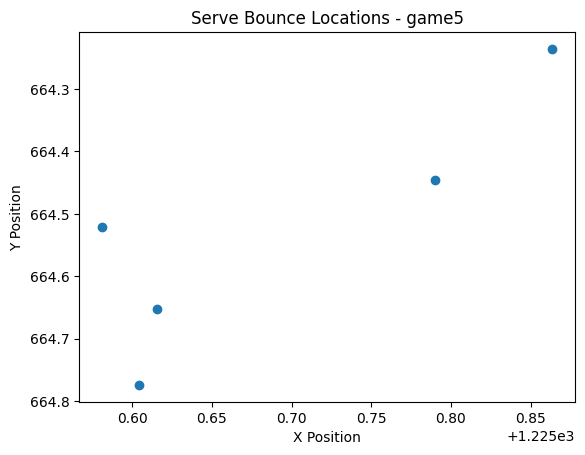

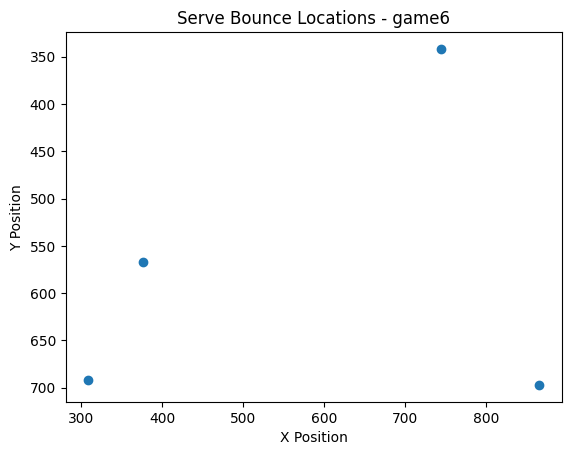

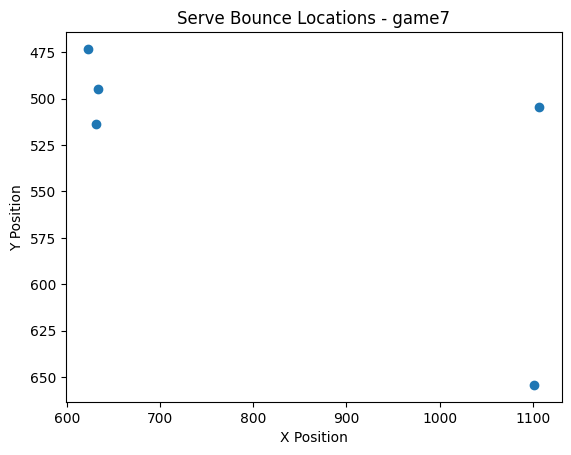

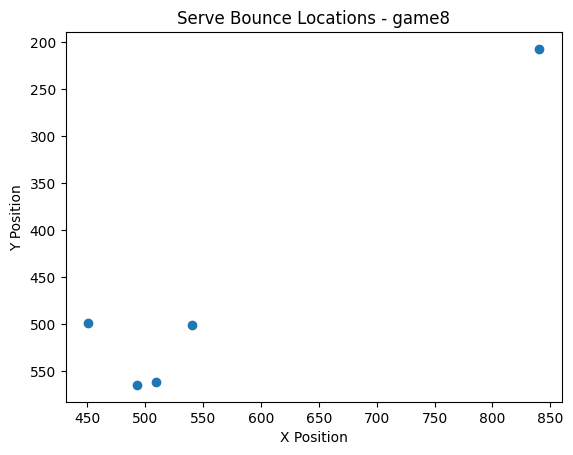

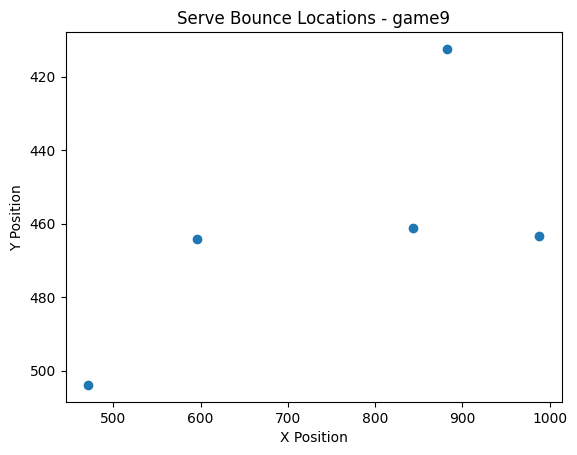

In [8]:
import matplotlib.pyplot as plt

for game in all_bounces:
    
    df = all_bounces[game]
    
    plt.figure()
    
    # Plot serve bounce locations
    plt.scatter(df["serve_x"], df["serve_y"])
    
    plt.gca().invert_yaxis()
    
    plt.title(f"Serve Bounce Locations - {game}")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    
    plt.show()

In [10]:
all_bounces_clustered = {}

# Loop through each game
for game in all_bounces:
    
    # Copy dataframe so we dont overwrite original
    df = all_bounces[game].copy()
    
    # If not enough points skip 
    if len(df) < 2:
        continue
    
    # Get all points for clustering
    points = df[["serve_x", "serve_y"]].values
    
    # Split points into 2 clusters (deuce side + ad side)
    kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
    
    # Train clustering model on serve locations
    kmeans.fit(points)
    
    # Get the center of each cluster (represents each service box)
    centers = kmeans.cluster_centers_
    
    # Store distance of each point to closest cluster
    distances = []
    
    # Loop through each serve bounce
    for p in points:
        
        # Distance to first cluster center
        d1 = np.linalg.norm(p - centers[0])
        
        # Distance to second cluster center
        d2 = np.linalg.norm(p - centers[1])
        
        # Take the closest distance (which service box its closest to)
        distances.append(min(d1, d2))
    
    # Add distances to dataframe
    df["distance"] = distances
    
    # Set threshold so that the 75% of the closest serves are classified as in
    threshold = np.percentile(distances, 75)
    
    # Classify each serve as in or out
    df["label"] = df["distance"].apply(
        lambda d: "IN" if d <= threshold else "OUT"
    )
    
    # Store results
    all_bounces_clustered[game] = df

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9946079080>
Traceback (most recent call last):
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_ve

In [11]:
# Save results for each game into csv files
for game in all_bounces_clustered:
    
    df = all_bounces_clustered[game]
    
    # Save dataframe to csv file
    df.to_csv(f"{game}_serve_results.csv", index=False)

/home/gholfes/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9924d5f920>
Traceback (most recent call last):
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
    

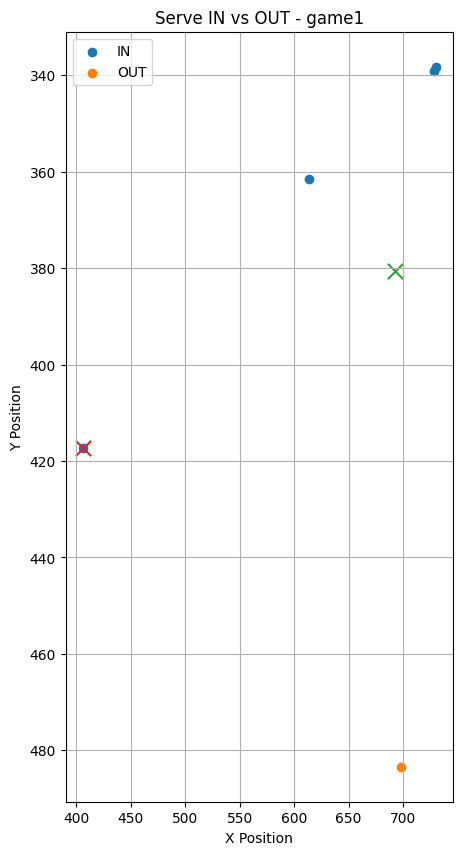

/home/gholfes/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9924d69f80>
Traceback (most recent call last):
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
    

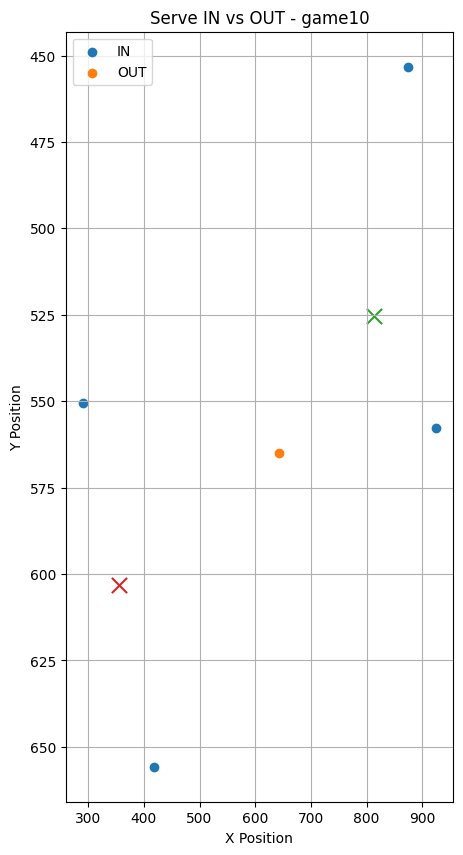

/home/gholfes/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f992c1982c0>
Traceback (most recent call last):
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
    

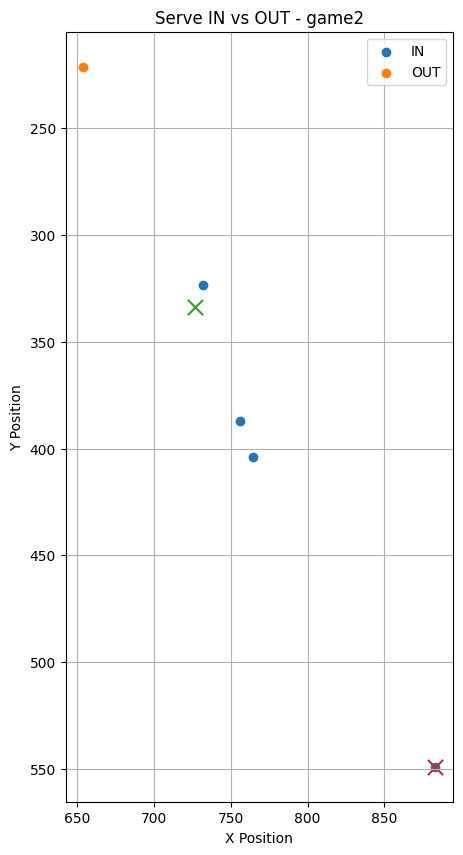

/home/gholfes/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f992c36c9a0>
Traceback (most recent call last):
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
    

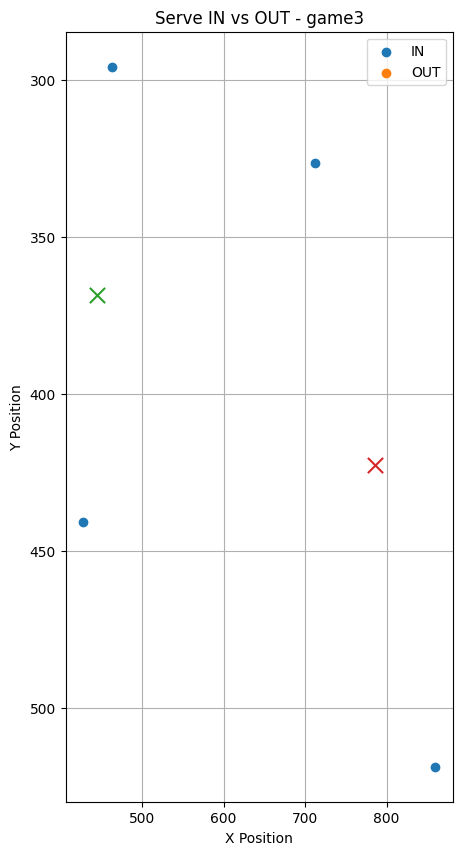

/home/gholfes/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f992c364b80>
Traceback (most recent call last):
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
    

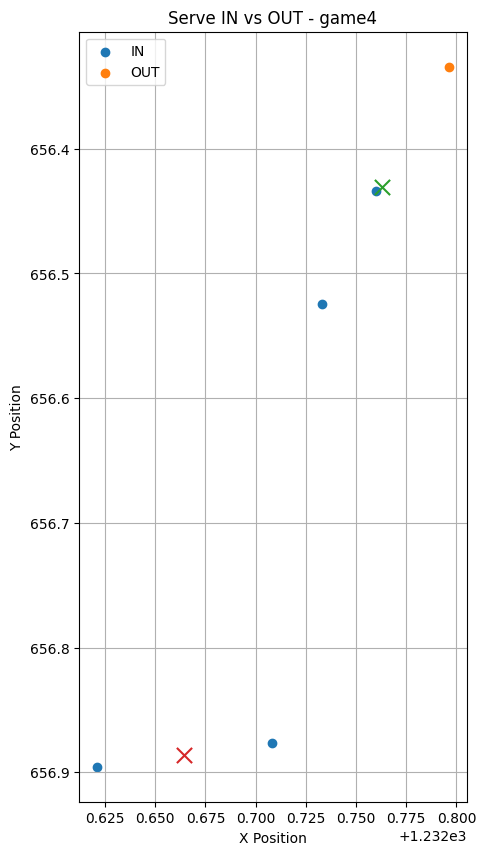

/home/gholfes/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f992c36f2e0>
Traceback (most recent call last):
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
    

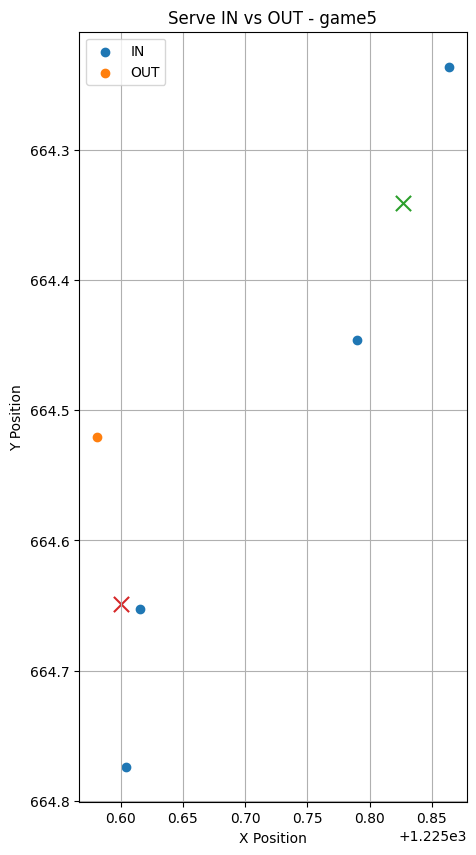

/home/gholfes/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f992c36f060>
Traceback (most recent call last):
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
    

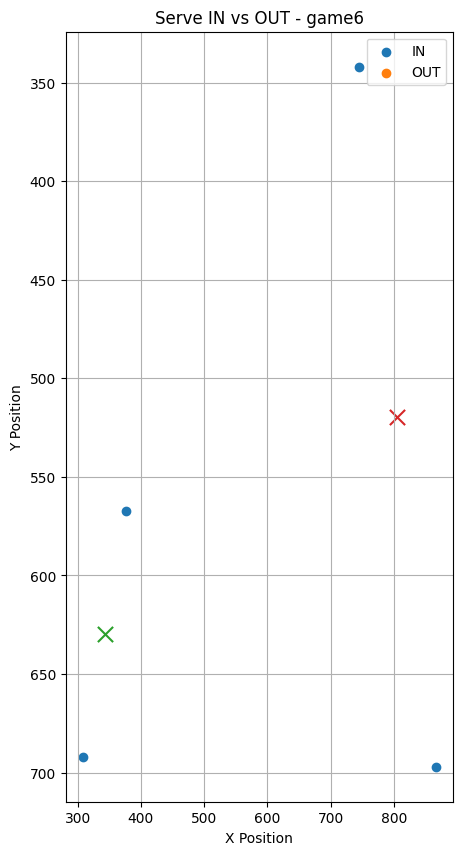

/home/gholfes/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f992c43db20>
Traceback (most recent call last):
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
    

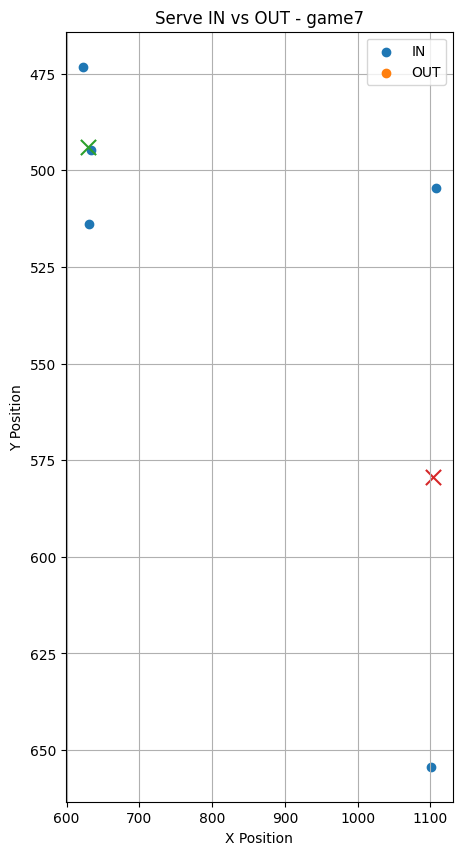

/home/gholfes/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f992c478220>
Traceback (most recent call last):
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
    

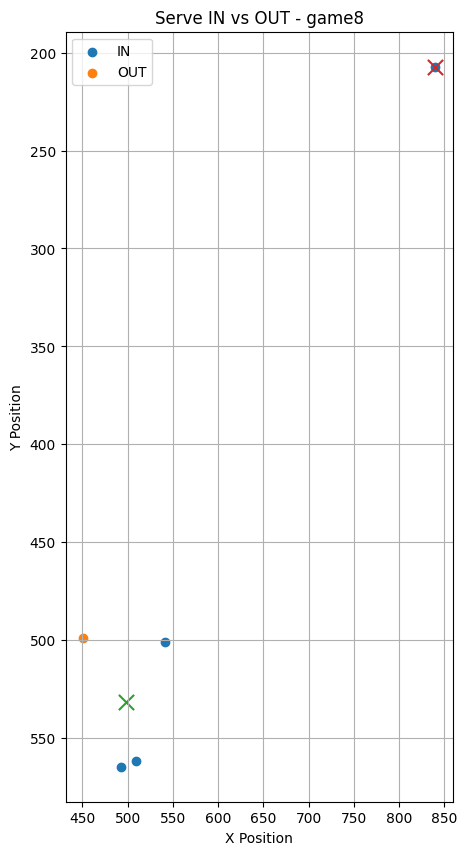

/home/gholfes/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9924cbf060>
Traceback (most recent call last):
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/software/slurm/spackages/linux-rocky8-x86_64/gcc-12.2.0/anaconda3-2023.09-0-3mhml42fa64byxqyd5fig5tbih625dp2/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
    

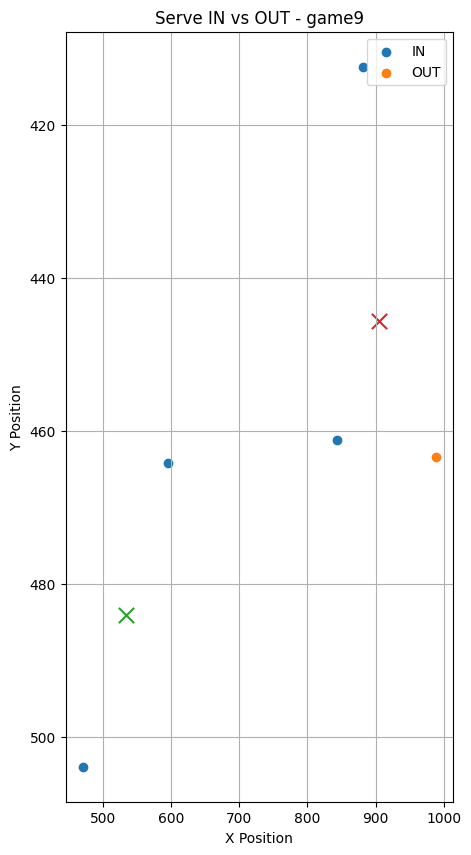

In [13]:
# Plot results for each game
for game in all_bounces_clustered:
    
    df = all_bounces_clustered[game]
    
    plt.figure(figsize=(5,10))
    
    # Plot IN serves
    in_df = df[df["label"] == "IN"]
    plt.scatter(in_df["serve_x"], in_df["serve_y"], label="IN")
    
    # Plot OUT serves
    out_df = df[df["label"] == "OUT"]
    plt.scatter(out_df["serve_x"], out_df["serve_y"], label="OUT")
    
    # Get points again for plotting cluster centers
    points = df[["serve_x", "serve_y"]].values
    
    # Refit KMeans to show centers on graph
    kmeans = KMeans(n_clusters=2, random_state=0).fit(points)
    
    # Plot cluster centers (service box centers)
    for c in kmeans.cluster_centers_:
        plt.scatter(c[0], c[1], marker="x", s=120)
    
    # Flip y-axis so it matches image coordinates
    plt.gca().invert_yaxis()
    
    plt.grid(True)
    plt.legend()
    
    plt.title(f"Serve IN vs OUT - {game}")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    
    plt.show()
    